# 02 — Attention differences and matched song-level comparisons

**Purpose.** Estimate film-linked differences in current Spotify popularity and cumulative
Last.fm listener reach (raw-unit and standardized), rerun the historical and prior-attention song-level matching
designs, and quantify replacement-aware matched uncertainty.

**Inputs.** `outputs/data/spotify_song_snapshot_panel.csv`, `outputs/data/lastfm_song_panel.csv`,
`outputs/data/master_song_panel.csv` (notebook 01).

**Outputs (result objects).** `results/attention_premiums.csv`, `results/standardized_premiums.csv`,
`results/song_matching_estimates.csv`, `results/song_matching_balance_long.csv`,
`results/song_matching_pairs.csv`, `results/song_matching_inference.csv`,
`results/pooled_premium_cluster_rows.csv`.

**Unit of analysis.** The Billboard song-artist record within a platform/snapshot.
All estimates are observational comparisons, not randomized contrasts.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "raw_checksums.csv").exists())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display

from cdr import paths, build, util
from cdr.util import SNAPSHOTS, SNAPSHOT_LABEL, check, show_and_save_table, show_and_save_figure

paths.ensure_output_dirs()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
RESULTS = paths.RESULTS

In [2]:
panel = pd.read_csv(paths.OUT_DATA / "spotify_song_snapshot_panel.csv", low_memory=False)
lastfm = pd.read_csv(paths.OUT_DATA / "lastfm_song_panel.csv", low_memory=False)
print(f"Spotify song-snapshots: {len(panel):,} | Last.fm records: {len(lastfm):,}")

Spotify song-snapshots: 83,785 | Last.fm records: 17,988


## Adjusted attention differences

Model (per snapshot, HC1 robust standard errors):

`attention ~ film_linked + age + age^2 + weeks + peak_pos`

The pooled Spotify model adds snapshot fixed effects. Spotify outcomes are platform popularity
points; Last.fm uses log1p cumulative listeners. For the pooled model, which reuses the same
song across snapshots, a cluster-by-song variant is also stored for the SI inference table.

In [3]:
FORMULA = "attention ~ film_linked + age + I(age**2) + weeks + peak_pos"

def premium_rows(data, platform):
    rows = []
    for snapshot, g in data.groupby("snapshot"):
        d = g.dropna(subset=["attention", "film_linked", "age", "weeks", "peak_pos"]).copy()
        mod = smf.ols(FORMULA, data=d).fit(cov_type="HC1")
        est, se, lo, hi, p = util.ci_from_model(mod, "film_linked")
        rows.append({"platform": platform, "snapshot": snapshot, "estimate": est, "std_error": se,
                     "conf_low": lo, "conf_high": hi, "p_value": p, "n_song_snapshots": int(mod.nobs),
                     "n_film_linked": int(d["film_linked"].sum())})
    return rows

rows = premium_rows(panel, "Spotify")
d_all = panel.dropna(subset=["attention", "film_linked", "age", "weeks", "peak_pos"]).copy()
pooled_hc1 = smf.ols(FORMULA + " + C(snapshot)", data=d_all).fit(cov_type="HC1")
pooled_cl = smf.ols(FORMULA + " + C(snapshot)", data=d_all).fit(cov_type="cluster", cov_kwds={"groups": d_all["song_artist_id"]})
est, se, lo, hi, p = util.ci_from_model(pooled_hc1, "film_linked")
rows.append({"platform": "Spotify", "snapshot": "pooled", "estimate": est, "std_error": se,
             "conf_low": lo, "conf_high": hi, "p_value": p, "n_song_snapshots": int(pooled_hc1.nobs),
             "n_film_linked": int(d_all["film_linked"].sum())})
rows += premium_rows(lastfm, "Last.fm")
premiums = pd.DataFrame(rows)
show_and_save_table(premiums, RESULTS / "attention_premiums.csv")

check(abs(premiums.loc[premiums["snapshot"].eq("2016-10") & premiums["platform"].eq("Spotify"), "estimate"].iloc[0] - 12.28) < 0.01, "October 2016 premium = 12.28")
check(abs(premiums.loc[premiums["snapshot"].eq("2017-07") & premiums["platform"].eq("Spotify"), "estimate"].iloc[0] - 13.36) < 0.01, "July 2017 premium = 13.36")
check(abs(premiums.loc[premiums["snapshot"].eq("2022-08") & premiums["platform"].eq("Spotify"), "estimate"].iloc[0] - 14.29) < 0.01, "August 2022 premium = 14.29")
check(abs(premiums.loc[premiums["snapshot"].eq("2025") & premiums["platform"].eq("Spotify"), "estimate"].iloc[0] - 15.09) < 0.01, "August 2025 premium = 15.09")
check(abs(premiums.loc[premiums["snapshot"].eq("pooled"), "estimate"].iloc[0] - 13.80) < 0.01, "pooled Spotify premium = 13.80")
check(abs(premiums.loc[premiums["platform"].eq("Last.fm"), "estimate"].iloc[0] - 1.78) < 0.01, "Last.fm log-listener premium = 1.78")

,platform,snapshot,estimate,std_error,conf_low,conf_high,p_value,n_song_snapshots,n_film_linked
0,Spotify,2016-10,12.275286,0.250492,11.784321,12.766251,0.0,17347,3825
1,Spotify,2017-07,13.357923,0.254458,12.859185,13.856661,0.0,18189,4133
2,Spotify,2022-08,14.292161,0.258608,13.785290,14.799032,0.0,22105,4373
3,Spotify,2025,15.088692,0.251537,14.595680,15.581705,0.0,26144,4616
4,Spotify,pooled,13.791698,0.127907,13.541001,14.042396,0.0,83785,16947
5,Last.fm,2017-07,1.779152,0.031760,1.716903,1.841402,0.0,17988,4090


PASS: October 2016 premium = 12.28
PASS: July 2017 premium = 13.36
PASS: August 2022 premium = 14.29
PASS: August 2025 premium = 15.09
PASS: pooled Spotify premium = 13.80
PASS: Last.fm log-listener premium = 1.78


### Standardized premiums (cross-platform comparability, main Figure 1A)

The outcome is standardized within each platform/snapshot before estimating the same model, so
Spotify points and Last.fm log-listeners are shown on an SD scale without equating current popularity with cumulative reach. A standardized
pooled cluster-by-song row is stored for the SI inference table.

In [4]:
std_rows = []
for platform, data in [("Spotify", panel), ("Last.fm", lastfm)]:
    for snapshot, g in data.groupby("snapshot"):
        d = g.dropna(subset=["attention", "film_linked", "age", "weeks", "peak_pos"]).copy()
        raw_mod = smf.ols(FORMULA, data=d).fit(cov_type="HC1")
        d["attention_std"] = (d["attention"] - d["attention"].mean()) / d["attention"].std(ddof=1)
        mod = smf.ols("attention_std ~ film_linked + age + I(age**2) + weeks + peak_pos", data=d).fit(cov_type="HC1")
        est, se, lo, hi, p = util.ci_from_model(mod, "film_linked")
        raw_est, raw_se, raw_lo, raw_hi, raw_p = util.ci_from_model(raw_mod, "film_linked")
        std_rows.append({
            "platform": platform, "snapshot": snapshot,
            "label": ("Spotify " if platform == "Spotify" else "Last.fm ") + SNAPSHOT_LABEL.get(snapshot, "July 2017"),
            "raw_outcome": "Spotify popularity" if platform == "Spotify" else "log1p Last.fm listeners",
            "raw_estimate": raw_est, "raw_conf_low": raw_lo, "raw_conf_high": raw_hi,
            "standardized_estimate": est, "std_error": se, "conf_low": lo, "conf_high": hi,
            "p_value": p, "n": int(mod.nobs),
        })
standardized = pd.DataFrame(std_rows)
show_and_save_table(standardized, RESULTS / "standardized_premiums.csv")

std_panel = d_all.copy()
std_panel["attention"] = std_panel.groupby("snapshot")["attention"].transform(lambda x: (x - x.mean()) / x.std(ddof=1))
std_hc1 = smf.ols(FORMULA + " + C(snapshot)", data=std_panel).fit(cov_type="HC1")
std_cl = smf.ols(FORMULA + " + C(snapshot)", data=std_panel).fit(cov_type="cluster", cov_kwds={"groups": std_panel["song_artist_id"]})

cluster_rows = pd.DataFrame([
    {"model": "Pooled broad Spotify film-linked premium", "term": "film_linked",
     "formula": FORMULA + " + C(snapshot)", "exposure_definition": "ever film-linked (exact IMDb soundtrack linkage)",
     "estimate": float(pooled_hc1.params["film_linked"]), "hc1_se": float(pooled_hc1.bse["film_linked"]),
     "cluster_se": float(pooled_cl.bse["film_linked"]),
     "cluster_ci_low": float(pooled_cl.params["film_linked"] - 1.96 * pooled_cl.bse["film_linked"]),
     "cluster_ci_high": float(pooled_cl.params["film_linked"] + 1.96 * pooled_cl.bse["film_linked"]),
     "cluster_p": float(pooled_cl.pvalues["film_linked"]),
     "n_observations": int(pooled_hc1.nobs), "n_clusters": int(d_all["song_artist_id"].nunique()),
     "interpretation": "selection-adjusted attention-regime association"},
    {"model": "Pooled standardized Spotify film-linked premium", "term": "film_linked",
     "formula": "standardized " + FORMULA + " + C(snapshot)", "exposure_definition": "ever film-linked",
     "estimate": float(std_hc1.params["film_linked"]), "hc1_se": float(std_hc1.bse["film_linked"]),
     "cluster_se": float(std_cl.bse["film_linked"]),
     "cluster_ci_low": float(std_cl.params["film_linked"] - 1.96 * std_cl.bse["film_linked"]),
     "cluster_ci_high": float(std_cl.params["film_linked"] + 1.96 * std_cl.bse["film_linked"]),
     "cluster_p": float(std_cl.pvalues["film_linked"]),
     "n_observations": int(std_hc1.nobs), "n_clusters": int(std_panel["song_artist_id"].nunique()),
     "interpretation": "standardized attention-regime association"},
])
show_and_save_table(cluster_rows, RESULTS / "pooled_premium_cluster_rows.csv")

,platform,snapshot,label,raw_outcome,raw_estimate,raw_conf_low,raw_conf_high,standardized_estimate,std_error,conf_low,conf_high,p_value,n
0,Spotify,2016-10,Spotify October 2016,Spotify popularity,12.275286,11.784321,12.766251,0.634627,0.012950,0.609244,0.660010,0.0,17347
1,Spotify,2017-07,Spotify July 2017,Spotify popularity,13.357923,12.859185,13.856661,0.661704,0.012605,0.636999,0.686410,0.0,18189
2,Spotify,2022-08,Spotify August 2022,Spotify popularity,14.292161,13.785290,14.799032,0.663199,0.012000,0.639678,0.686719,0.0,22105
3,Spotify,2025,Spotify August 2025,Spotify popularity,15.088692,14.595680,15.581705,0.663901,0.011068,0.642209,0.685594,0.0,26144
4,Last.fm,2017-07,Last.fm July 2017,log1p Last.fm listeners,1.779152,1.716903,1.841402,0.740475,0.013218,0.714567,0.766383,0.0,17988


,model,term,formula,exposure_definition,estimate,hc1_se,cluster_se,cluster_ci_low,cluster_ci_high,cluster_p,n_observations,n_clusters,interpretation
0,Pooled broad Spotify film-linked premium,film_linked,attention ~ film_linked + age + I(age**2) + we...,ever film-linked (exact IMDb soundtrack linkage),13.791698,0.127907,0.226929,13.346918,14.236478,0.0,83785,28281,selection-adjusted attention-regime association
1,Pooled standardized Spotify film-linked premium,film_linked,standardized attention ~ film_linked + age + I...,ever film-linked,0.655913,0.006052,0.010787,0.634770,0.677056,0.0,83785,28281,standardized attention-regime association


,model,term,formula,exposure_definition,estimate,hc1_se,cluster_se,cluster_ci_low,cluster_ci_high,cluster_p,n_observations,n_clusters,interpretation
0,Pooled broad Spotify film-linked premium,film_linked,attention ~ film_linked + age + I(age**2) + we...,ever film-linked (exact IMDb soundtrack linkage),13.791698,0.127907,0.226929,13.346918,14.236478,0.0,83785,28281,selection-adjusted attention-regime association
1,Pooled standardized Spotify film-linked premium,film_linked,standardized attention ~ film_linked + age + I...,ever film-linked,0.655913,0.006052,0.010787,0.634770,0.677056,0.0,83785,28281,standardized attention-regime association


## Matched song-level comparisons

Nearest-neighbor matching **with replacement**, within each high-coverage snapshot:

- **Historical matching** balances chart year, song age, Billboard weeks, peak position, and
  five artist-level historical covariates (catalog size, total and mean weeks excluding the
  focal song, best other-song peak, top-1% superstar indicator).
- **Prior-attention matching** additionally balances the previous high-coverage snapshot's
  Spotify popularity with a **five-point caliper** (available from July 2017 onward).

Distances are standardized Euclidean; missing covariate values are median-imputed in the
matching space only. Matching does not make film placement random or exogenous.

In [5]:
from cdr.matching import nearest_neighbor_match, summarize_pairs

BASE_COVS = [
    "chart_year", "age", "weeks", "peak_pos",
    "artist_catalog_size_excl_song", "artist_total_weeks_excl_song",
    "artist_mean_weeks_excl_song", "artist_best_peak_excl_song", "artist_superstar_top1pct",
]
CALIPER_POINTS = 5.0

summary_rows, balance_rows, all_pairs = [], [], []
for snapshot, g in panel.groupby("snapshot"):
    for design, covs, cal_col, cal in [
        ("historical + artist-success NN", BASE_COVS, None, None),
        ("baseline-attention + historical + artist-success NN", BASE_COVS + ["previous_popularity"], "previous_popularity", CALIPER_POINTS),
    ]:
        if design.startswith("baseline") and snapshot == "2016-10":
            continue  # no previous high-coverage snapshot exists for October 2016
        dd = g.dropna(subset=["attention", "film_linked"]).copy()
        if cal_col:
            dd = dd[dd[cal_col].notna()].copy()
        pairs, balance = nearest_neighbor_match(dd, "film_linked", covs, caliper_col=cal_col, caliper=cal)
        summary_rows.append(summarize_pairs(pairs, balance, design, snapshot,
                                            int(dd["film_linked"].eq(1).sum()), int(dd["film_linked"].eq(0).sum())))
        balance["design"], balance["snapshot"], balance["family"] = design, snapshot, "song film-linked matching"
        balance_rows.append(balance)
        pairs["design"], pairs["snapshot"] = design, snapshot
        all_pairs.append(pairs)

matching_summary = pd.DataFrame(summary_rows)
balance_long = pd.concat(balance_rows, ignore_index=True)
pairs_all = pd.concat(all_pairs, ignore_index=True)
pairs_all.to_csv(RESULTS / "song_matching_pairs.csv", index=False)
show_and_save_table(matching_summary, RESULTS / "song_matching_estimates.csv")
show_and_save_table(balance_long, RESULTS / "song_matching_balance_long.csv", max_rows=12)

def est(snapshot, prefix):
    m = matching_summary[matching_summary["snapshot"].eq(snapshot) & matching_summary["design"].str.startswith(prefix)]
    return float(m["estimate"].iloc[0])

check(abs(est("2016-10", "historical") - 10.16) < 0.03, "historical matched premium 2016 = 10.16")
check(abs(est("2017-07", "historical") - 11.17) < 0.03, "historical matched premium 2017 = 11.17")
check(abs(est("2022-08", "historical") - 11.25) < 0.03, "historical matched premium 2022 = 11.25")
check(abs(est("2025", "historical") - 11.68) < 0.03, "historical matched premium 2025 = 11.68")
check(abs(est("2017-07", "baseline") - 1.95) < 0.03, "baseline-attention matched premium 2017 = 1.95")
check(abs(est("2022-08", "baseline") - 2.23) < 0.03, "baseline-attention matched premium 2022 = 2.23")
check(abs(est("2025", "baseline") - 1.96) < 0.03, "baseline-attention matched premium 2025 = 1.96")
check(matching_summary.loc[matching_summary["design"].str.startswith("baseline"), "max_abs_smd_after"].max() < 0.05,
      "maximum absolute SMD after baseline-attention matching < 0.05")

,design,snapshot,n_treated_available,n_matched_treated,n_unique_controls,n_controls_available,replacement,estimate,std_error,conf_low,conf_high,p_value,max_abs_smd_before,max_abs_smd_after
0,historical + artist-success NN,2016-10,3825,3825,2749,13522,with replacement,10.165490,0.258692,9.658454,10.672526,5.361795e-284,0.691567,0.031383
1,historical + artist-success NN,2017-07,4133,4133,2961,14056,with replacement,11.182434,0.260001,10.672833,11.692035,0.000000e+00,0.741834,0.026305
2,baseline-attention + historical + artist-succe...,2017-07,3798,3798,2307,11415,with replacement,1.952080,0.129163,1.698920,2.205240,3.706721e-50,0.772197,0.046054
3,historical + artist-success NN,2022-08,4373,4373,3197,17732,with replacement,11.257946,0.277685,10.713683,11.802210,2.378677e-305,0.748851,0.024058
4,baseline-attention + historical + artist-succe...,2022-08,3950,3950,2469,13037,with replacement,2.231392,0.169672,1.898836,2.563949,1.077107e-38,0.837163,0.040505
5,historical + artist-success NN,2025,4616,4616,3426,21528,with replacement,11.675260,0.267938,11.150101,12.200419,0.000000e+00,0.759786,0.022696
6,baseline-attention + historical + artist-succe...,2025,4349,4349,2829,17246,with replacement,1.955852,0.134788,1.691668,2.220036,1.255939e-46,0.825936,0.039483


,covariate,treated_mean_before,control_mean_before,smd_before,treated_mean_after,control_mean_after,smd_after,design,snapshot,family
0,chart_year,1981.644183,1986.633782,-0.294555,1981.644183,1981.842353,-0.012849,historical + artist-success NN,2016-10,song film-linked matching
1,age,35.155817,30.166218,0.294555,35.155817,34.957647,0.012849,historical + artist-success NN,2016-10,song film-linked matching
2,weeks,15.795033,11.624686,0.496656,15.795033,15.522876,0.031383,historical + artist-success NN,2016-10,song film-linked matching
3,peak_pos,26.441830,46.157151,-0.691567,26.441830,26.651503,-0.007707,historical + artist-success NN,2016-10,song film-linked matching
4,artist_catalog_size_excl_song,14.698039,14.324508,0.018578,14.698039,14.587190,0.007117,historical + artist-success NN,2016-10,song film-linked matching
5,artist_total_weeks_excl_song,167.346667,142.427156,0.142764,167.346667,166.196078,0.006513,historical + artist-success NN,2016-10,song film-linked matching
6,artist_mean_weeks_excl_song,11.545736,11.619594,-0.014570,11.545736,11.555902,-0.002131,historical + artist-success NN,2016-10,song film-linked matching
7,artist_best_peak_excl_song,13.495734,14.092741,-0.028193,13.495734,13.252936,0.011362,historical + artist-success NN,2016-10,song film-linked matching
8,artist_superstar_top1pct,0.166797,0.139698,0.075275,0.166797,0.166797,0.000000,historical + artist-success NN,2016-10,song film-linked matching
9,chart_year,1981.620857,1984.214143,-0.154932,1981.620857,1981.753206,-0.008517,historical + artist-success NN,2017-07,song film-linked matching


PASS: historical matched premium 2016 = 10.16
PASS: historical matched premium 2017 = 11.17
PASS: historical matched premium 2022 = 11.25
PASS: historical matched premium 2025 = 11.68
PASS: baseline-attention matched premium 2017 = 1.95
PASS: baseline-attention matched premium 2022 = 2.23
PASS: baseline-attention matched premium 2025 = 1.96
PASS: maximum absolute SMD after baseline-attention matching < 0.05


## Control-reuse diagnostics and replacement-aware inference

Matching with replacement reuses control songs, so the naive paired standard error understates
uncertainty. For each design we report the naive paired SE, a bootstrap over matched treated
pairs, and a cluster bootstrap over reused control units, plus design sensitivities
(no-replacement, stricter two-point caliper, and coarsened exact matching on chart decade x
baseline-popularity quintile) evaluated at the August 2025 snapshot.

In [6]:
from cdr.matching import replacement_aware_inference, cem_estimate

reuse = (
    pairs_all.groupby(["design", "snapshot"])
    .apply(lambda g: pd.Series({
        "n_pairs": len(g),
        "n_unique_controls": g["control_song_artist_id"].nunique(),
        "median_control_reuse": g["control_song_artist_id"].value_counts().median(),
        "p95_control_reuse": g["control_song_artist_id"].value_counts().quantile(0.95),
        "max_control_reuse": g["control_song_artist_id"].value_counts().max(),
    }), include_groups=False)
    .reset_index()
)
show_and_save_table(reuse, RESULTS / "song_matching_control_reuse.csv")

rng = np.random.default_rng(20260603)
inference_rows = []
for (design, snapshot), g in pairs_all.groupby(["design", "snapshot"]):
    if snapshot != "2025":
        continue
    g = g.copy()
    g["control_key"] = g["control_song_artist_id"]
    r = replacement_aware_inference(g, f"{design} | 2025 (with replacement)", rng)
    r.update({"design": design, "snapshot": snapshot, "variant": "with replacement"})
    inference_rows.append(r)

p25 = panel[panel["snapshot"].eq("2025")].copy()
SENSITIVITY_COVS = ["chart_year", "age", "weeks", "peak_pos", "artist_catalog_size_excl_song", "artist_total_weeks_excl_song", "artist_superstar_top1pct"]
for design, covs, cal_col, cal in [
    ("historical + artist-success NN", SENSITIVITY_COVS, None, None),
    ("baseline-attention + historical + artist-success NN", SENSITIVITY_COVS + ["previous_popularity"], "previous_popularity", 5.0),
]:
    pr_nr, _ = nearest_neighbor_match(p25.dropna(subset=["attention", "film_linked"]), "film_linked", covs,
                                      caliper_col=cal_col, caliper=cal, replace=False, max_candidates=60)
    if not pr_nr.empty:
        e, se, lo, hi, p = util.ci_mean(pr_nr["diff"])
        inference_rows.append({"comparison": f"{design} | 2025 (no replacement)", "design": design, "snapshot": "2025",
                               "variant": "no replacement", "n_matched_pairs": len(pr_nr),
                               "n_unique_controls": int(pr_nr["control_song_artist_id"].nunique()),
                               "control_reuse_share": 0.0, "estimate": float(e), "naive_paired_se": float(se),
                               "naive_ci_low": lo, "naive_ci_high": hi})
    if cal_col:
        pr_cal, _ = nearest_neighbor_match(p25.dropna(subset=["attention", "film_linked"]), "film_linked", covs,
                                           caliper_col=cal_col, caliper=2.0)
        e, se, lo, hi, p = util.ci_mean(pr_cal["diff"])
        inference_rows.append({"comparison": f"{design} | 2025 (stricter caliper 2.0)", "design": design, "snapshot": "2025",
                               "variant": "stricter caliper", "n_matched_pairs": len(pr_cal),
                               "n_unique_controls": int(pr_cal["control_song_artist_id"].nunique()),
                               "control_reuse_share": float(1 - pr_cal["control_song_artist_id"].nunique() / len(pr_cal)),
                               "estimate": float(e), "naive_paired_se": float(se), "naive_ci_low": lo, "naive_ci_high": hi})
        cem, n_cem = cem_estimate(p25, "film_linked")
        inference_rows.append({"comparison": f"{design} | 2025 (CEM decade x baseline-pop quintile)", "design": design,
                               "snapshot": "2025", "variant": "CEM", "n_matched_pairs": n_cem, "estimate": cem})

song_inference = pd.DataFrame(inference_rows)
show_and_save_table(song_inference, RESULTS / "song_matching_inference.csv")
wr = song_inference[song_inference["variant"].eq("with replacement")]
check((wr["cluster_control_se"] >= wr["naive_paired_se"] * 0.9).all(),
      "cluster-by-control SEs computed for all with-replacement designs")
check((song_inference.dropna(subset=["estimate"])["estimate"] > 0).all(),
      "song-level matched premium remains positive across all inference variants and designs")

,design,snapshot,n_pairs,n_unique_controls,median_control_reuse,p95_control_reuse,max_control_reuse
0,baseline-attention + historical + artist-succe...,2017-07,3798.0,2307.0,1.0,4.0,15.0
1,baseline-attention + historical + artist-succe...,2022-08,3950.0,2469.0,1.0,4.0,15.0
2,baseline-attention + historical + artist-succe...,2025,4349.0,2829.0,1.0,4.0,13.0
3,historical + artist-success NN,2016-10,3825.0,2749.0,1.0,3.0,12.0
4,historical + artist-success NN,2017-07,4133.0,2961.0,1.0,3.0,12.0
5,historical + artist-success NN,2022-08,4373.0,3196.0,1.0,3.0,11.0
6,historical + artist-success NN,2025,4616.0,3426.0,1.0,3.0,11.0


,comparison,n_matched_pairs,n_unique_controls,control_reuse_share,estimate,naive_paired_se,naive_ci_low,naive_ci_high,boot_treated_se,boot_treated_ci_low,boot_treated_ci_high,cluster_control_se,cluster_control_ci_low,cluster_control_ci_high,design,snapshot,variant
0,baseline-attention + historical + artist-succe...,4349,2829.0,0.349506,1.955852,0.134788,1.691668,2.220036,0.127659,1.728472,2.224511,0.166959,1.626735,2.291807,baseline-attention + historical + artist-succe...,2025,with replacement
1,historical + artist-success NN | 2025 (with re...,4616,3426.0,0.257799,11.675260,0.267938,11.150101,12.200419,0.263280,11.092629,12.168593,0.333438,11.016985,12.358291,historical + artist-success NN,2025,with replacement
2,historical + artist-success NN | 2025 (no repl...,4561,4561.0,0.000000,12.533655,0.278212,11.988360,13.078950,NaN,NaN,NaN,NaN,NaN,NaN,historical + artist-success NN,2025,no replacement
3,baseline-attention + historical + artist-succe...,3746,3745.0,0.000000,2.319274,0.153594,2.018230,2.620318,NaN,NaN,NaN,NaN,NaN,NaN,baseline-attention + historical + artist-succe...,2025,no replacement
4,baseline-attention + historical + artist-succe...,4341,2844.0,0.344851,1.344851,0.134411,1.081406,1.608297,NaN,NaN,NaN,NaN,NaN,NaN,baseline-attention + historical + artist-succe...,2025,stricter caliper
5,baseline-attention + historical + artist-succe...,4339,NaN,NaN,3.028520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,baseline-attention + historical + artist-succe...,2025,CEM


PASS: cluster-by-control SEs computed for all with-replacement designs
PASS: song-level matched premium remains positive across all inference variants and designs


## Paper artifacts for this section

Figure 1 and the attention-premium and song-matching SI tables are generated here, from the result objects this notebook produces.

In [3]:
# Paper-artifact helpers: shared figure style, LaTeX writers, result-object reader.
from matplotlib.gridspec import GridSpec

from cdr import tex
from cdr.tex import fmt_num, fmt_int, fmt_p, fmt_ci
from cdr.util import (ACCENT, BLUE, CHARCOAL, COV_LABEL, DARK_BLUE, GRAY, GREEN, GRID,
                      LIGHT_BLUE, LIGHT_GRAY, SNAP_SHORT, errorbarh, errorbarv,
                      panel_label, set_plot_style)

set_plot_style()
R = lambda name: pd.read_csv(RESULTS / name, low_memory=False)

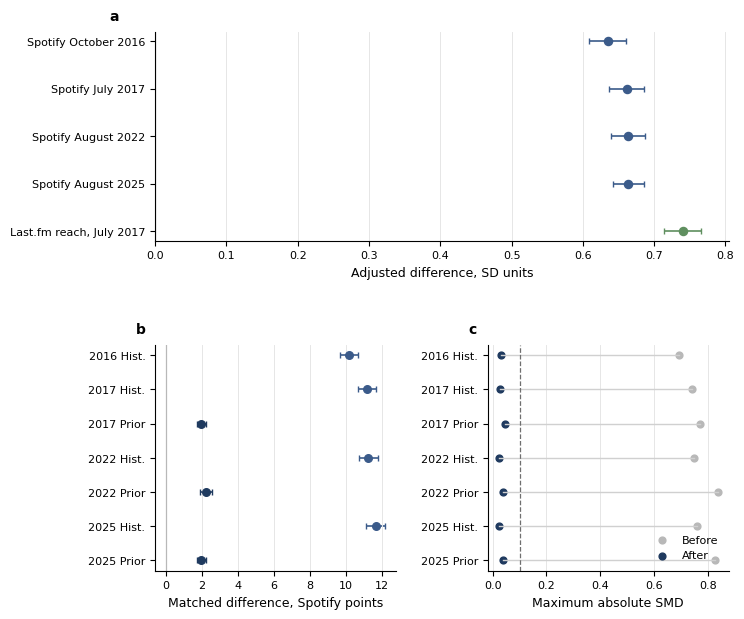

In [4]:
std = R("standardized_premiums.csv")
msum = R("song_matching_estimates.csv")

def plot_fig1_a(ax):
    order = ["Spotify October 2016", "Spotify July 2017", "Spotify August 2022", "Spotify August 2025", "Last.fm July 2017"]
    d = std.set_index("label").loc[order].reset_index()
    y = np.arange(len(d))
    for i, row in d.iterrows():
        errorbarh(ax, row["standardized_estimate"], row["conf_low"], row["conf_high"], [y[i]],
                  color=BLUE if row["platform"] == "Spotify" else GREEN, size=34)
    ax.axvline(0, color=LIGHT_GRAY, lw=0.9)
    ax.set_yticks(y); ax.set_yticklabels(d["label"].str.replace("Last.fm July", "Last.fm reach, July", regex=False)); ax.invert_yaxis()
    ax.set_xlabel("Adjusted difference, SD units"); ax.grid(axis="x", color=GRID, lw=0.7)
    ax.set_xlim(left=min(0, d["conf_low"].min() - 0.05))

MATCH_ORDER = [("2016-10", "historical", "2016 Hist."), ("2017-07", "historical", "2017 Hist."), ("2017-07", "baseline", "2017 Prior"),
               ("2022-08", "historical", "2022 Hist."), ("2022-08", "baseline", "2022 Prior"), ("2025", "historical", "2025 Hist."), ("2025", "baseline", "2025 Prior")]
def match_rows():
    rows, labels = [], []
    for snap, kind, label in MATCH_ORDER:
        mask = msum["snapshot"].eq(snap) & msum["design"].str.startswith("historical" if kind == "historical" else "baseline-attention")
        rows.append(msum[mask].iloc[0]); labels.append(label)
    return pd.DataFrame(rows), labels

def plot_fig1_b(ax):
    d, labels = match_rows()
    y = np.arange(len(d))
    for i, (_, row) in enumerate(d.iterrows()):
        errorbarh(ax, row["estimate"], row["conf_low"], row["conf_high"], [y[i]], color=DARK_BLUE if "Prior" in labels[i] else BLUE)
    ax.axvline(0, color=LIGHT_GRAY, lw=0.9)
    ax.set_yticks(y); ax.set_yticklabels(labels); ax.invert_yaxis()
    ax.set_xlabel("Matched difference, Spotify points"); ax.grid(axis="x", color=GRID, lw=0.7)

def plot_fig1_c(ax):
    d, labels = match_rows()
    y = np.arange(len(d))
    ax.scatter(d["max_abs_smd_before"], y, color=LIGHT_GRAY, s=24, label="Before")
    ax.scatter(d["max_abs_smd_after"], y, color=DARK_BLUE, s=24, label="After")
    for i, (_, row) in enumerate(d.iterrows()):
        ax.plot([row["max_abs_smd_before"], row["max_abs_smd_after"]], [y[i], y[i]], color="#D0D0D0", lw=1)
    ax.axvline(0.1, color=GRAY, lw=0.9, ls="--")
    ax.set_yticks(y); ax.set_yticklabels(labels); ax.invert_yaxis()
    ax.set_xlabel("Maximum absolute SMD"); ax.grid(axis="x", color=GRID, lw=0.7)
    ax.legend(frameon=False, loc="lower right")

fig = plt.figure(figsize=(7.4, 7.0))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1.0, 1.08], hspace=0.48, wspace=0.38)
ax_a = fig.add_subplot(gs[0, :]); ax_b = fig.add_subplot(gs[1, 0]); ax_c = fig.add_subplot(gs[1, 1])
plot_fig1_a(ax_a); plot_fig1_b(ax_b); plot_fig1_c(ax_c)
panel_label(ax_a, "a"); panel_label(ax_b, "b"); panel_label(ax_c, "c")
show_and_save_figure(fig, paths.OUT_FIG_MAIN / "figure1_attention_regimes_matching.pdf")

In [5]:
# S: attention premiums (raw + standardized + Last.fm) -- C5
prem = R("attention_premiums.csv")
rows = []
for _, r in std.iterrows():
    rows.append([r["platform"], r["label"].replace("Spotify ", "").replace("Last.fm ", ""), r["raw_outcome"],
                 fmt_num(r["raw_estimate"]), fmt_ci(r["raw_conf_low"], r["raw_conf_high"]),
                 fmt_num(r["standardized_estimate"]), fmt_ci(r["conf_low"], r["conf_high"]), fmt_int(r["n"])])
pooled_prem = prem[prem["snapshot"].eq("pooled")].iloc[0]
rows.append(["Spotify", "pooled (snapshot FE)", "Spotify popularity", fmt_num(pooled_prem["estimate"]), fmt_ci(pooled_prem["conf_low"], pooled_prem["conf_high"]), "--", "--", fmt_int(pooled_prem["n_song_snapshots"])])
tex.write_table(paths.OUT_TABLES_SI / "table_si_attention_premiums.tex",
    "Film-linked attention differences in raw and standardized units.", "tab:si-attention-premiums",
    ["Platform", "Snapshot", "Raw outcome", r"\makecell[b]{Raw\\ estimate}", r"\makecell[b]{Raw\\ 95\% CI}", r"\makecell[b]{SD\\ estimate}", r"\makecell[b]{SD\\ 95\% CI}", "N"],
    rows,
    note="Models adjust for song age, squared age, Billboard weeks, and peak chart position; intervals use HC1 robust standard errors. Standardized (SD) estimates divide the outcome by its within-platform/snapshot standard deviation for the cross-platform comparison in the main attention-differences figure. Spotify measures current popularity and Last.fm measures cumulative listener reach. The pooled Spotify model adds snapshot fixed effects; its cluster-by-song variant appears in the SI inference table.",
    col_spec=r">{\raggedright\arraybackslash}p{0.08\linewidth}>{\raggedright\arraybackslash}p{0.115\linewidth}>{\raggedright\arraybackslash}p{0.12\linewidth}>{\centering\arraybackslash}p{0.075\linewidth}>{\centering\arraybackslash}p{0.10\linewidth}>{\centering\arraybackslash}p{0.075\linewidth}>{\centering\arraybackslash}p{0.095\linewidth}>{\centering\arraybackslash}p{0.065\linewidth}",
    size=r"\footnotesize", stretch=1.05, escape_cells=False)

**Film-linked attention differences in raw and standardized units.** (`tab:si-attention-premiums`)

,Platform,Snapshot,Raw outcome,Raw estimate,Raw 95% CI,SD estimate,SD 95% CI,N
0,Spotify,October 2016,Spotify popularity,12.28,"[11.78, 12.77]",0.63,"[0.61, 0.66]","17,347"
1,Spotify,July 2017,Spotify popularity,13.36,"[12.86, 13.86]",0.66,"[0.64, 0.69]","18,189"
2,Spotify,August 2022,Spotify popularity,14.29,"[13.79, 14.80]",0.66,"[0.64, 0.69]","22,105"
3,Spotify,August 2025,Spotify popularity,15.09,"[14.60, 15.58]",0.66,"[0.64, 0.69]","26,144"
4,Last.fm,July 2017,log1p Last.fm listeners,1.78,"[1.72, 1.84]",0.74,"[0.71, 0.77]","17,988"
5,Spotify,pooled (snapshot FE),Spotify popularity,13.79,"[13.54, 14.04]",--,--,"83,785"


In [6]:
# S: song matching estimates -- C11, C12
rows = []
for _, r in msum.iterrows():
    rows.append([("Historical" if r["design"].startswith("historical") else "Prior-attention"), SNAP_SHORT.get(r["snapshot"], r["snapshot"]),
                 fmt_int(r["n_treated_available"]), fmt_int(r["n_matched_treated"]), fmt_int(r["n_unique_controls"]),
                 fmt_num(r["estimate"]), fmt_ci(r["conf_low"], r["conf_high"]), fmt_num(r["max_abs_smd_after"], 3)])
tex.write_table(paths.OUT_TABLES_SI / "table_si_song_matching_estimates.tex",
    "Matched song-level attention premiums by snapshot and design.", "tab:si-song-matching-estimates",
    ["Design", "Snapshot", r"\makecell[b]{Treated\\ available}", "Matched", r"\makecell[b]{Unique\\ controls}", "Estimate", "95\\% CI", r"\makecell[b]{Max\\ $|$SMD$|$\\ after}"],
    rows,
    note="Nearest-neighbor matching with replacement. Historical designs balance chart year, age, Billboard weeks, peak position, and artist-level historical covariates; prior-attention designs additionally balance the previous high-coverage snapshot's popularity with a five-point caliper. Intervals use paired standard errors; replacement-aware inference is reported in the matching-inference table.",
    size=r"\footnotesize", stretch=1.05, escape_cells=False)


# S: song matching replacement-aware inference -- C14 (wait: C13 is balance; reuse threat id C14 per matrix -> song inference)
si_inf = R("song_matching_inference.csv")
rows = []
for _, r in si_inf.iterrows():
    rows.append([r.get("comparison", ""), r.get("variant", ""), fmt_int(r.get("n_matched_pairs")), fmt_int(r.get("n_unique_controls")),
                 fmt_num(r.get("estimate")), fmt_num(r.get("naive_paired_se"), 3), fmt_num(r.get("boot_treated_se"), 3), fmt_num(r.get("cluster_control_se"), 3),
                 (fmt_ci(r.get("cluster_control_ci_low"), r.get("cluster_control_ci_high")) if pd.notna(r.get("cluster_control_ci_low")) else fmt_ci(r.get("naive_ci_low"), r.get("naive_ci_high")))])
tex.write_table(paths.OUT_TABLES_SI / "table_si_song_matching_inference.tex",
    "Replacement-aware inference and design sensitivity for the song-level matched premium (August 2025).", "tab:si-song-matching-inference",
    ["Comparison", "Variant", "Pairs", r"\makecell[b]{Unique\\ controls}", "Estimate", r"\makecell[b]{Naive\\ SE}", r"\makecell[b]{Bootstrap\\ SE\\ (treated)}", r"\makecell[b]{Cluster\\ SE\\ (control)}", "95\\% CI"],
    rows,
    note="Matching with replacement reuses control songs, so the cluster bootstrap over reused control units is the primary uncertainty check; the bootstrap over treated pairs and the naive paired SE are shown for comparison. No-replacement, stricter-caliper, and coarsened-exact-matching (chart decade $\\times$ baseline-popularity quintile) variants are design sensitivities. The interval column reports the cluster-by-control interval where computed and the naive interval otherwise.",
    col_spec=r">{\raggedright\arraybackslash}p{0.135\linewidth}>{\raggedright\arraybackslash}p{0.15\linewidth}>{\centering\arraybackslash}p{0.058\linewidth}>{\centering\arraybackslash}p{0.078\linewidth}>{\centering\arraybackslash}p{0.082\linewidth}>{\centering\arraybackslash}p{0.052\linewidth}>{\centering\arraybackslash}p{0.09\linewidth}>{\centering\arraybackslash}p{0.082\linewidth}>{\centering\arraybackslash}p{0.10\linewidth}",
    size=r"\footnotesize", stretch=1.05, tabcolsep="2.5pt", escape_cells=False)

**Matched song-level attention premiums by snapshot and design.** (`tab:si-song-matching-estimates`)

,Design,Snapshot,Treated available,Matched,Unique controls,Estimate,95% CI,Max |SMD| after
0,Historical,2016,"3,825","3,825","2,749",10.17,"[9.66, 10.67]",0.031
1,Historical,2017,"4,133","4,133","2,961",11.18,"[10.67, 11.69]",0.026
2,Prior-attention,2017,"3,798","3,798","2,307",1.95,"[1.70, 2.21]",0.046
3,Historical,2022,"4,373","4,373","3,197",11.26,"[10.71, 11.80]",0.024
4,Prior-attention,2022,"3,950","3,950","2,469",2.23,"[1.90, 2.56]",0.041
5,Historical,2025,"4,616","4,616","3,426",11.68,"[11.15, 12.20]",0.023
6,Prior-attention,2025,"4,349","4,349","2,829",1.96,"[1.69, 2.22]",0.039


**Replacement-aware inference and design sensitivity for the song-level matched premium (August 2025).** (`tab:si-song-matching-inference`)

,Comparison,Variant,Pairs,Unique controls,Estimate,Naive SE,Bootstrap SE (treated),Cluster SE (control),95% CI
0,baseline-attention + historical + artist-succe...,with replacement,"4,349","2,829",1.96,0.135,0.128,0.167,"[1.63, 2.29]"
1,historical + artist-success NN | 2025 (with re...,with replacement,"4,616","3,426",11.68,0.268,0.263,0.333,"[11.02, 12.36]"
2,historical + artist-success NN | 2025 (no repl...,no replacement,"4,561","4,561",12.53,0.278,--,--,"[11.99, 13.08]"
3,baseline-attention + historical + artist-succe...,no replacement,"3,746","3,745",2.32,0.154,--,--,"[2.02, 2.62]"
4,baseline-attention + historical + artist-succe...,stricter caliper,"4,341","2,844",1.34,0.134,--,--,"[1.08, 1.61]"
5,baseline-attention + historical + artist-succe...,CEM,"4,339",--,3.03,--,--,--,--
